# EDA — Defasagem, autoavaliação, psicossocial e psicopedagógico

Bloco B do storytelling (`docs/fontes/enunciado-datathon.md`): perguntas 1,
4, 5 e 6, mais uma investigação à parte sobre por que o eixo `psicossocial`
nunca aparece como driver dominante em `notebooks/01_modelagem.ipynb`.

Fonte: `data/processed/panel_longitudinal.csv` e `data/processed/features.csv`
(deltas ano a ano). Decisões de consolidação em
`docs/decisions/0001-consolidacao-painel.md`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

panel = pd.read_csv("../data/processed/panel_longitudinal.csv")
feats = pd.read_csv("../data/processed/features.csv")

print(f"painel: {len(panel)} linhas | features: {len(feats)} linhas")

painel: 3030 linhas | features: 1874 linhas


## Q1 — Perfil de defasagem (IAN) e evolução ao longo do ano

O IAN só assume 3 valores discretos, que mapeiam direto pra faixas de
`defasagem` (Fase Efetiva − Fase Ideal):

| IAN | Defasagem | Categoria |
|---|---|---|
| 10,0 | ≥ 0 (adequado/adiantado) | Adequado |
| 5,0 | -1 ou -2 | Moderado |
| 2,5 | ≤ -3 | Severo |

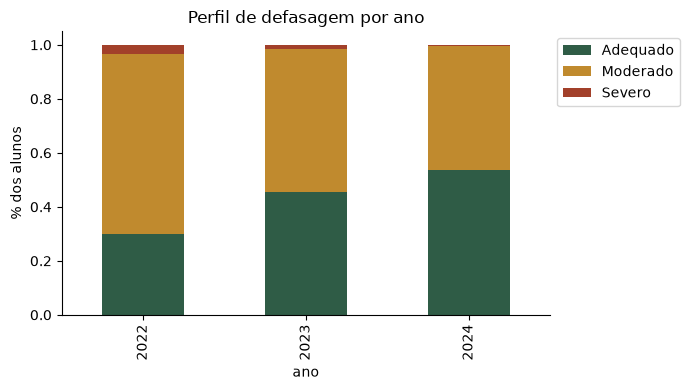

categoria_ian  Adequado  Moderado  Severo
ano                                      
2022               30.1      66.6     3.3
2023               45.6      53.1     1.4
2024               53.8      45.9     0.3

contagem absoluta 2024:
categoria_ian
Adequado    622
Moderado    531
Severo        3
Name: count, dtype: int64


In [2]:
CAT_IAN = {10.0: "Adequado", 5.0: "Moderado", 2.5: "Severo"}
panel["categoria_ian"] = panel["ian"].map(CAT_IAN)

perfil = pd.crosstab(panel["ano"], panel["categoria_ian"], normalize="index")[["Adequado", "Moderado", "Severo"]]

fig, ax = plt.subplots(figsize=(7, 4))
perfil.plot(kind="bar", stacked=True, ax=ax, color=["#2f5c46", "#c08a2e", "#a2402a"])
ax.set_title("Perfil de defasagem por ano")
ax.set_ylabel("% dos alunos")
ax.legend(title="", loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

print((perfil * 100).round(1))
print()
print("contagem absoluta 2024:")
print(panel[panel.ano == 2024]["categoria_ian"].value_counts())

**Resposta:** o perfil melhora de ano a ano, no agregado — adequados sobem de
30% (2022) pra 54% (2024), moderados caem de 67% pra 46%, e severos quase
desaparecem (3,3% → 0,3%, só 3 alunos em 2024). Ressalva: isso é corte
transversal (safra inteira de cada ano, não os mesmos alunos), e a Q10 já
mostrou que o INDE da coorte que ficou os 3 anos fica estável — parte dessa
melhora agregada pode vir de composição de safra (quem está mais defasado
tem mais chance de evadir, ver `evasao` correlacionando negativo com IDA/IEG
na investigação do IPS abaixo), não necessariamente de melhora individual.

## Q4 — A autoavaliação (IAA) é coerente com IDA e IEG reais?

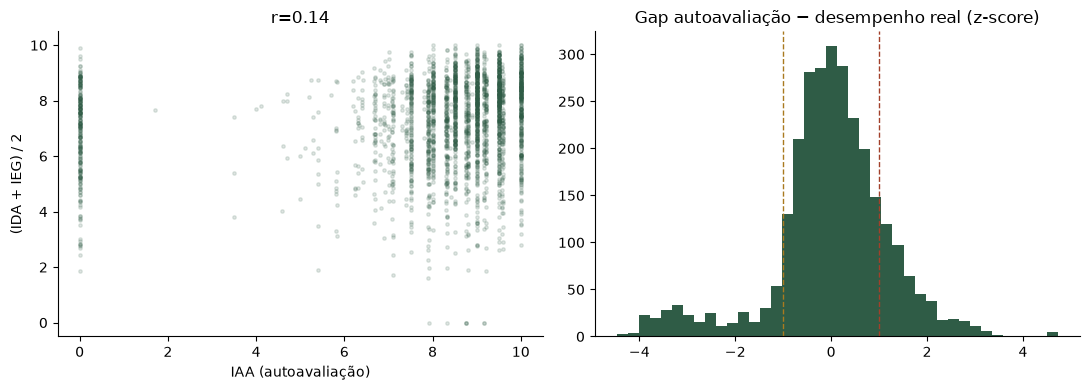

       iaa    ida    ieg
iaa  1.000  0.115  0.131
ida  0.115  1.000  0.543
ieg  0.131  0.543  1.000

superconfiantes (gap > 1 desvio): 16.5%
subestimados (gap < -1 desvio): 11.6%


In [3]:
d = panel.dropna(subset=["iaa", "ida", "ieg"]).copy()
corr_iaa = d[["iaa", "ida", "ieg"]].corr()

z_iaa = (d["iaa"] - d["iaa"].mean()) / d["iaa"].std()
z_real = ((d["ida"] - d["ida"].mean()) / d["ida"].std() + (d["ieg"] - d["ieg"].mean()) / d["ieg"].std()) / 2
gap = z_iaa - z_real  # positivo = se acha melhor do que é; negativo = se subestima

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(d["iaa"], (d["ida"] + d["ieg"]) / 2, s=6, alpha=0.15, color="#2f5c46")
axes[0].set_xlabel("IAA (autoavaliação)")
axes[0].set_ylabel("(IDA + IEG) / 2")
axes[0].set_title(f"r={np.corrcoef(d['iaa'], (d['ida']+d['ieg'])/2)[0,1]:.2f}")

axes[1].hist(gap, bins=40, color="#2f5c46")
axes[1].axvline(1, color="#a2402a", linestyle="--", linewidth=1)
axes[1].axvline(-1, color="#a97a1f", linestyle="--", linewidth=1)
axes[1].set_title("Gap autoavaliação − desempenho real (z-score)")
plt.tight_layout()
plt.show()

print(corr_iaa.round(3))
print()
print(f"superconfiantes (gap > 1 desvio): {(gap > 1).mean():.1%}")
print(f"subestimados (gap < -1 desvio): {(gap < -1).mean():.1%}")

**Resposta:** não, coerência baixa. IAA correlaciona fraco com IDA (r=0,12) e
IEG (r=0,13) — a autoavaliação do aluno quase não acompanha o desempenho ou
engajamento real. 16,5% dos alunos se autoavaliam bem acima do que os dados
mostram (superconfiantes) e 11,6% bem abaixo (se subestimam) — quase 3 em
cada 10 alunos têm uma percepção de si bem descolada da realidade medida.

## Q5 — Há padrões de IPS que antecedem quedas de desempenho ou engajamento?

Usa `features.csv`: IPS no ano `t` contra a variação de IDA/IEG de `t` pra
`t+1` (`delta_ida`, `delta_ieg`). Correlação linear direta primeiro, depois
por tercil de IPS — pra pegar um efeito de limiar que a correlação linear
pode estar escondendo.

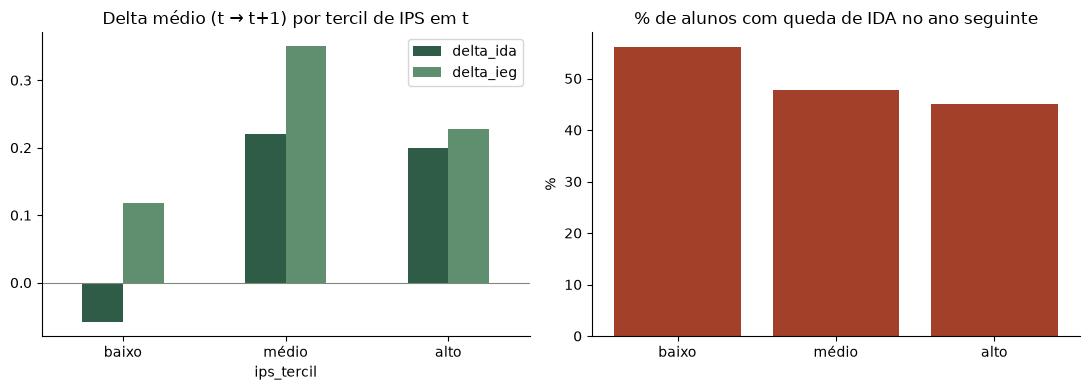

correlação linear IPS(t) x delta:
 delta_ida    0.063
delta_ieg    0.039
Name: ips, dtype: float64

            delta_ida  delta_ieg
ips_tercil                      
baixo          -0.059      0.118
médio           0.220      0.351
alto            0.199      0.228

% com queda de IDA por tercil:
 ips_tercil
baixo    56.2
médio    47.8
alto     45.0
dtype: float64

n por tercil: {'baixo': 203, 'alto': 189, 'médio': 178}


In [4]:
f2 = feats.dropna(subset=["ips", "delta_ida", "delta_ieg"]).copy()
corr_ips_delta = f2[["ips", "delta_ida", "delta_ieg"]].corr()

f2["ips_tercil"] = pd.qcut(f2["ips"], 3, labels=["baixo", "médio", "alto"])
por_tercil = f2.groupby("ips_tercil", observed=True)[["delta_ida", "delta_ieg"]].mean()
queda_ida = f2.groupby("ips_tercil", observed=True).apply(lambda g: (g["delta_ida"] < 0).mean())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
por_tercil.plot(kind="bar", ax=axes[0], color=["#2f5c46", "#5f8f6f"])
axes[0].axhline(0, color="#7c8a78", linewidth=.8)
axes[0].set_title("Delta médio (t → t+1) por tercil de IPS em t")
axes[0].tick_params(axis="x", rotation=0)

axes[1].bar(queda_ida.index, queda_ida.values * 100, color="#a2402a")
axes[1].set_title("% de alunos com queda de IDA no ano seguinte")
axes[1].set_ylabel("%")
plt.tight_layout()
plt.show()

print("correlação linear IPS(t) x delta:\n", corr_ips_delta["ips"].drop("ips").round(3))
print()
print(por_tercil.round(3))
print()
print("% com queda de IDA por tercil:\n", (queda_ida * 100).round(1))
print("\nn por tercil:", f2["ips_tercil"].value_counts().to_dict())

**Resposta:** sim, mas fraco e não-linear — a correlação direta é quase nula
(r=0,06 com delta_ida, r=0,04 com delta_ieg), mas o tercil mais baixo de IPS
se comporta diferente: em média, tem queda de IDA no ano seguinte (-0,06)
enquanto médio e alto têm ganho (+0,22 e +0,20), e 56% do tercil baixo cai de
IDA no ano seguinte contra 45% do tercil alto. Ou seja, IPS muito baixo é um
sinal de alerta real, só não é um sinal forte o bastante pra virar o driver
principal de nenhum modelo — consistente com a investigação abaixo.

## Q6 — O IPP confirma ou contradiz a defasagem identificada pelo IAN?

IPP só existe a partir de 2023 (`docs/decisions/0001`). "Contradição" aqui é
concreta: aluno com defasagem severa/moderada (IAN ≤ 5) mas IPP alto (≥ 7,5,
sem sinal psicopedagógico de problema), ou o inverso — IAN adequado (10) com
IPP baixo (≤ 5).

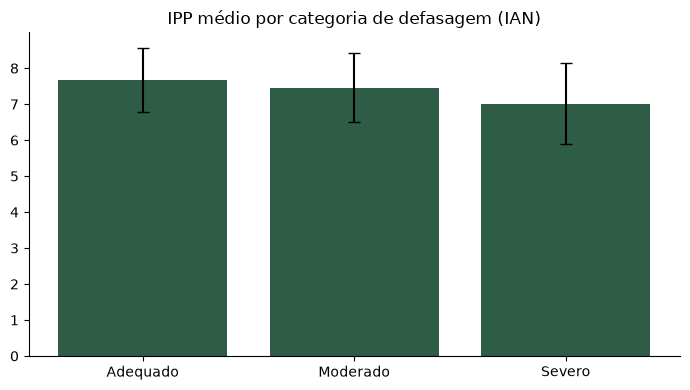

             ipp    ian  defasagem
ipp        1.000  0.123      0.182
ian        0.123  1.000      0.855
defasagem  0.182  0.855      1.000

               mean   std  count
categoria_ian                   
Adequado       7.68  0.89    908
Moderado       7.46  0.96   1067
Severo         7.01  1.13     17

defasado (IAN<10) com IPP alto (≥7,5): 33.2%
adequado (IAN=10) com IPP baixo (≤5): 0.5%


In [5]:
d = panel.dropna(subset=["ipp", "ian", "defasagem"]).copy()
corr_ipp = d[["ipp", "ian", "defasagem"]].corr()

d["categoria_ian"] = d["ian"].map(CAT_IAN)
perfil_ipp = d.groupby("categoria_ian", observed=True)["ipp"].agg(["mean", "std", "count"]).loc[["Adequado", "Moderado", "Severo"]]

contradicao_defasado_ipp_alto = ((d["categoria_ian"] != "Adequado") & (d["ipp"] >= 7.5)).mean()
contradicao_adequado_ipp_baixo = ((d["categoria_ian"] == "Adequado") & (d["ipp"] <= 5)).mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(perfil_ipp.index, perfil_ipp["mean"], yerr=perfil_ipp["std"], color="#2f5c46", capsize=4)
ax.set_title("IPP médio por categoria de defasagem (IAN)")
plt.tight_layout()
plt.show()

print(corr_ipp.round(3))
print()
print(perfil_ipp.round(2))
print()
print(f"defasado (IAN<10) com IPP alto (≥7,5): {contradicao_defasado_ipp_alto:.1%}")
print(f"adequado (IAN=10) com IPP baixo (≤5): {contradicao_adequado_ipp_baixo:.1%}")

**Resposta:** parcialmente contradiz. A tendência é a esperada — IPP médio
cai de 7,68 (Adequado) pra 7,46 (Moderado) e 7,01 (Severo, n=17, amostra
pequena) — mas a diferença é pequena (menos de 1 ponto em 10) e existe uma
contradição concreta relevante: **33% dos alunos com defasagem (IAN<10) têm
IPP alto (≥7,5)**, ou seja, a avaliação psicopedagógica não sinaliza problema
nenhum num terço dos casos que o IAN já classificou como atrasados. Já o
inverso é raro (0,5%: quase nenhum aluno "adequado" tem IPP baixo). O IPP
confirma bem quem está indo bem, mas concorda pouco com o tamanho do
problema de quem está defasado.

## Investigação extra — por que o IPS nunca é driver dominante?

No `notebooks/01_modelagem.ipynb`, o eixo `psicossocial` (SHAP, agrupamento
em `src/tc5/explain.py`) nunca vence como driver dominante em nenhum dos dois
modelos. Três hipóteses a descartar: (1) muito `NaN`, (2) baixa variância,
(3) baixa correlação real com os alvos.

In [6]:
outros = ["ida", "ieg", "ipp", "iaa", "ian"]
print("(1) missingness — % de NaN por indicador (features.csv):")
print(feats[["ips"] + outros].isna().mean().round(3))

print("\n(2) variância — desvio-padrão (mesma escala 0-10):")
print(feats[["ips"] + outros].std().round(2))

print("\n(3) correlação com os alvos:")
corr_targets = feats[["ips"] + outros + ["evasao", "piora_defasagem"]].corr()[["evasao", "piora_defasagem"]].drop(["evasao", "piora_defasagem"])
print(corr_targets.round(3))

print("\ndiferença de média por grupo de alvo (evasão sim/não, piora sim/não):")
comp = feats.groupby("evasao")[["ips"] + outros].mean().diff().iloc[-1]
comp2 = feats.groupby("piora_defasagem")[["ips"] + outros].mean().diff().iloc[-1]
print(pd.DataFrame({"gap_evasao": comp, "gap_piora_defasagem": comp2}).round(3))

(1) missingness — % de NaN por indicador (features.csv):
ips    0.037
ida    0.041
ieg    0.041
ipp    0.499
iaa    0.034
ian    0.000
dtype: float64

(2) variância — desvio-padrão (mesma escala 0-10):
ips    1.90
ida    1.85
ieg    1.43
ipp    0.98
iaa    3.04
ian    2.50
dtype: float64

(3) correlação com os alvos:
     evasao  piora_defasagem
ips   0.007            0.056
ida  -0.230           -0.084
ieg  -0.315           -0.025
ipp  -0.090           -0.248
iaa  -0.054            0.001
ian  -0.104            0.282

diferença de média por grupo de alvo (evasão sim/não, piora sim/não):
     gap_evasao  gap_piora_defasagem
ips       0.030                0.279
ida      -0.947               -0.373
ieg      -1.009               -0.079
ipp      -0.201               -0.635
iaa      -0.371                0.005
ian      -0.588                1.863


**Resposta:** é falta de sinal real, não descarte silencioso. IPS não é mais
faltante que os outros (3,7% de NaN, na mesma faixa de IDA/IEG/IAA — quem
realmente falta muito é IPP, 49,9%, ausente em todo 2022) e não tem baixa
variância (desvio 1,90, comparável a IDA e IAN). O que quebra é a correlação
com os alvos: IPS tem r=0,007 com evasão e r=0,056 com piora de defasagem —
de longe o mais fraco dos 6 indicadores (IEG chega a r=-0,32 com evasão, IAN
a r=0,28 com piora de defasagem). Na diferença de médias por grupo, o gap de
IPS é quase zero (0,03 pra evasão) contra gaps de quase 1 ponto em IDA/IEG.
Documentado em `docs/decisions/0002-ips-sem-sinal-preditivo.md`.